# ATIVIDADE AVALIATIVA I — Aprendizado de Máquina I
**Curso:** Ciência de Dados  
**Professor:** Prof. Me. Mateus Guilherme Fuini  
**Integrantes:**  
* Caio Roberto Farias Saraiva  
* Rodolfo Vinicius Cima Takemoto  
**Algoritmo Obrigatório:** K-Nearest Neighbors (K-NN)  
**Variável-alvo:** classe  

---
### Questão Central da Atividade
> *Qual configuração de K-NN apresenta a melhor capacidade de generalização para o conjunto de dados recebido e quais evidências sustentam essa decisão?*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11


---
## 1. Conhecimento Inicial do Conjunto de Dados

Nesta etapa realizamos a carga e a análise exploratória inicial do dataset para compreender:
- Quantidade de registros e atributos;
- Tipos de dados e valores nulos;
- Distribuição da variável-alvo (`classe`);
- Comportamento estatístico e disparidade de escalas entre os atributos previsores.


In [2]:
# Carregamento dos dados
df = pd.read_csv('dataset.csv')

print(f"Dimensões do conjunto de dados: {df.shape[0]} registros e {df.shape[1]} colunas (12 atributos previsores + 1 variável-alvo)")
print("\n--- Informações dos Tipos de Dados e Nulos ---")
print(df.info())

print("\n--- Distribuição Absoluta e Relativa das Classes ---")
dist_classes = pd.DataFrame({
    'Quantidade': df['classe'].value_counts(),
    'Proporção (%)': (df['classe'].value_counts(normalize=True) * 100).round(2)
})
print(dist_classes)

print("\n--- Resumo Estatístico dos Atributos Previsores ---")
display(df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])


Dimensões do conjunto de dados: 750 registros e 13 colunas (12 atributos previsores + 1 variável-alvo)

--- Informações dos Tipos de Dados e Nulos ---
<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   indice_01  750 non-null    float64
 1   indice_02  750 non-null    float64
 2   indice_03  750 non-null    float64
 3   indice_04  750 non-null    float64
 4   indice_05  750 non-null    float64
 5   indice_06  750 non-null    float64
 6   indice_07  750 non-null    float64
 7   indice_08  750 non-null    float64
 8   indice_09  750 non-null    float64
 9   indice_10  750 non-null    float64
 10  indice_11  750 non-null    float64
 11  indice_12  750 non-null    float64
 12  classe     750 non-null    str    
dtypes: float64(12), str(1)
memory usage: 80.7 KB
None

--- Distribuição Absoluta e Relativa das Classes ---
        Quantidade  Proporção (%)
classe      

,mean,std,min,25%,50%,75%,max
indice_01,425.604249,811.489835,-2905.912218,-60.894116,460.162902,953.018093,3415.187767
indice_02,-1.136167,30.364415,-125.492955,-22.153213,-1.382895,20.536183,81.684987
indice_03,-1.407727,0.461726,-2.520064,-1.755526,-1.466916,-1.098339,0.045338
indice_04,4985.283212,21501.283936,-54043.254063,-10006.511542,4272.546721,18160.386632,88708.057635
indice_05,1.966489,0.084308,1.651623,1.908856,1.960121,2.022158,2.266971
indice_06,-496.998691,3414.931984,-11885.738014,-2772.417438,-546.228554,1940.388894,9097.022874
indice_07,-4.096837,1.916179,-10.150161,-5.447792,-3.935440,-2.678861,0.488881
indice_08,0.896020,0.051747,0.730863,0.860923,0.895752,0.930650,1.045686
indice_09,-1785.609468,9955.115524,-36790.695699,-8534.542514,-1285.803837,5755.835749,26192.128215
indice_10,0.397179,0.050181,0.245855,0.359907,0.397067,0.430365,0.526393


C:\Users\takem\AppData\Local\Temp\ipykernel_34084\1940360042.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='classe', palette='mako', ax=axes[0])
C:\Users\takem\AppData\Local\Temp\ipykernel_34084\1940360042.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stds.values, y=stds.index, palette='viridis', ax=axes[1])


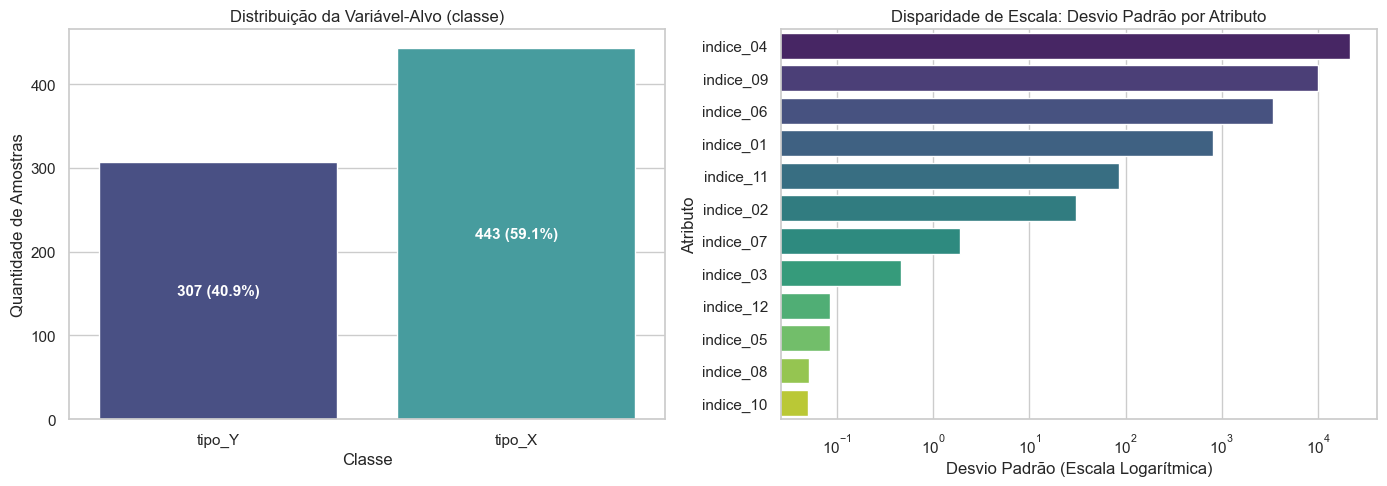

In [3]:
# Evidência Gráfica 1: Distribuição das Classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='classe', palette='mako', ax=axes[0])
axes[0].set_title('Distribuição da Variável-Alvo (classe)')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Quantidade de Amostras')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())} ({p.get_height()/len(df):.1%})',
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')

# Evidência Gráfica 2: Disparidade de Escalas (Desvio Padrão por Atributo)
stds = df.drop(columns=['classe']).std().sort_values(ascending=False)
sns.barplot(x=stds.values, y=stds.index, palette='viridis', ax=axes[1])
axes[1].set_title('Disparidade de Escala: Desvio Padrão por Atributo')
axes[1].set_xlabel('Desvio Padrão (Escala Logarítmica)')
axes[1].set_ylabel('Atributo')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()


### Análise Obrigatória da Seção 1
**Pergunta:** *Antes de construir o modelo, quais características do conjunto de dados podem influenciar o comportamento de um algoritmo baseado em distância?*

**Resposta Técnica:**
1. **Diferenças Brutais de Escala e Magnitude:** O K-NN classifica observações calculando distâncias geométricas (como a distância Euclidiana: $d(u,v) = \sqrt{\sum (u_i - v_i)^2}$). Em nosso conjunto de dados, o atributo `indice_04` varia de **-54.043 a +88.708** (desvio padrão $\approx 21.501$), enquanto o atributo `indice_05` varia apenas entre **1,65 e 2,27** (desvio padrão $\approx 0,08$) e `indice_10` entre **0,24 e 0,52** (desvio padrão $\approx 0,05$). Sem uma padronização prévia, o atributo `indice_04` domina mais de 99% da soma quadrática da distância, tornando atributos com valores menores totalmente irrelevantes para o algoritmo, independentemente do seu poder preditivo real.
2. **Leve Desbalanceamento de Classes:** A classe `tipo_X` representa **59,07%** (443 amostras) e `tipo_Y` representa **40,93%** (307 amostras). Embora não seja um desbalanceamento extremo, a densidade ligeiramente maior de pontos da classe majoritária no espaço de atributos pode puxar votos na vizinhança do K-NN, reforçando a necessidade de avaliar com métricas macro-ponderadas e utilizar divisão estratificada.
3. **Ausência de Nulos:** Não há valores ausentes (0 nulos), permitindo utilizar todas as 750 observações sem necessidade de imputação.


---
## 2. Preparação dos Dados para Experimentação

Separação dos atributos previsores ($X$) da variável-alvo ($y$) com proporção 75% treino e 25% teste, fixando `random_state = 42`.


In [4]:
X = df.drop(columns=['classe'])
y = df['classe']

# Divisão dos dados com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Conjunto de Treinamento: {X_train.shape[0]} amostras ({X_train.shape[0]/len(df):.1%})")
print(f"Conjunto de Teste: {X_test.shape[0]} amostras ({X_test.shape[0]/len(df):.1%})")

df_split_comp = pd.DataFrame({
    'Treino (%)': (y_train.value_counts(normalize=True)*100).round(2),
    'Teste (%)': (y_test.value_counts(normalize=True)*100).round(2),
    'Original (%)': (y.value_counts(normalize=True)*100).round(2)
})
print("\nDemonstração da Estratificação:")
print(df_split_comp)


Conjunto de Treinamento: 562 amostras (74.9%)
Conjunto de Teste: 188 amostras (25.1%)

Demonstração da Estratificação:
        Treino (%)  Teste (%)  Original (%)
classe                                     
tipo_X       59.07      59.04         59.07
tipo_Y       40.93      40.96         40.93


### Questão da Seção 2
**Pergunta:** *A distribuição das classes deve ser considerada durante a divisão entre treino e teste? Justifique a decisão adotada e demonstre que a separação realizada é adequada.*

**Resposta Técnica:**
**Sim, a distribuição das classes deve ser rigorosamente considerada através da amostragem estratificada (`stratify=y`).**
- **Finalidade:** Em problemas de classificação, uma divisão aleatória simples pode gerar distorções por variabilidade amostral, fazendo com que o conjunto de teste receba uma fração maior ou menor de uma das classes em relação ao treino. A estratificação força os subconjuntos particionados a espelharem exatamente a mesma distribuição populacional da variável-alvo.
- **Demonstração de adequação:** Conforme comprovado na tabela acima, a proporção original de **59,07% (`tipo_X`)** e **40,93% (`tipo_Y`)** foi rigorosamente preservada no treino (**59,07% vs 40,93%**) e no teste (**59,04% vs 40,96%**), garantindo que tanto o aprendizado dos vizinhos quanto a avaliação da generalização ocorram sob condições probabilísticas idênticas e justas.


---
## 3. Construção de um Modelo de Referência (Baseline)

Construção de um modelo baseline utilizando K-NN com $k=5$ **sem escalonamento de atributos**.


Métricas no Teste (Baseline k=5 sem escala):
Accuracy:  0.5532
Precision (Macro): 0.5262
Recall (Macro):    0.5242
F1-score (Macro):  0.5220


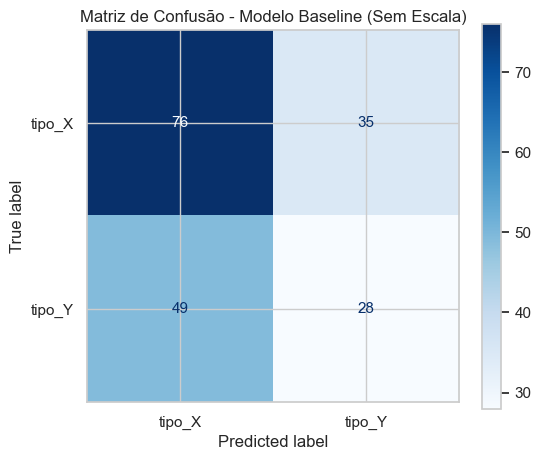


Relatório de Classificação Completo:
              precision    recall  f1-score   support

      tipo_X       0.61      0.68      0.64       111
      tipo_Y       0.44      0.36      0.40        77

    accuracy                           0.55       188
   macro avg       0.53      0.52      0.52       188
weighted avg       0.54      0.55      0.54       188



In [5]:
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train, y_train)

y_pred_base_train = knn_baseline.predict(X_train)
y_pred_base_test = knn_baseline.predict(X_test)

# Métricas
acc_base = accuracy_score(y_test, y_pred_base_test)
prec_base = precision_score(y_test, y_pred_base_test, average='macro')
rec_base = recall_score(y_test, y_pred_base_test, average='macro')
f1_base = f1_score(y_test, y_pred_base_test, average='macro')

print(f"Métricas no Teste (Baseline k=5 sem escala):")
print(f"Accuracy:  {acc_base:.4f}")
print(f"Precision (Macro): {prec_base:.4f}")
print(f"Recall (Macro):    {rec_base:.4f}")
print(f"F1-score (Macro):  {f1_base:.4f}")

# Matriz de Confusão
cm_base = confusion_matrix(y_test, y_pred_base_test, labels=['tipo_X', 'tipo_Y'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['tipo_X', 'tipo_Y'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title("Matriz de Confusão - Modelo Baseline (Sem Escala)")
plt.show()

print("\nRelatório de Classificação Completo:")
print(classification_report(y_test, y_pred_base_test, target_names=['tipo_X', 'tipo_Y']))


### Questão da Seção 3
**Pergunta:** *Qual estratégia de cálculo de Precision, Recall e F1 foi utilizada e por que ela é adequada ao conjunto de dados recebido?*

**Resposta Técnica:**
Foi adotada a estratégia **Macro-Average (`average='macro'`)**.
- **Justificativa:** A abordagem *macro* calcula a métrica (Precisão, Recall e F1-score) separadamente para cada uma das classes (`tipo_X` e `tipo_Y`) de forma aritmética simples: $\text{F1}_{\text{macro}} = \frac{\text{F1}_{X} + \text{F1}_{Y}}{2}$.
- **Por que é adequada:** Ao contrário da abordagem *weighted* (que pondera o F1 pelo número de amostras de cada classe), a abordagem *macro* atribui **o mesmo peso e importância a ambas as classes**. Como a classe `tipo_Y` possui menos exemplos (40,9%), a métrica weighted esconderia um fraco desempenho na classe minoritária. O baseline obteve F1 de apenas 0,40 na classe `tipo_Y`, derrubando o F1-macro para **0,5220**, evidenciando com fidelidade que o modelo não escalonado é quase equivalente a um chute aleatório.


---
## 4. Investigação da Escala dos Atributos

Comparação entre três experimentos mantendo $k=5$:
- **Experimento A:** Dados originais (sem escalonamento)
- **Experimento B:** MinMaxScaler ($[0, 1]$)
- **Experimento C:** StandardScaler ($\mu=0, \sigma=1$)

*Nota de integridade metodológica:* Os escalonadores são ajustados (`fit`) exclusivamente no conjunto de treino e aplicados (`transform`) no treino e no teste para prevenir vazamento de dados (*data leakage*).


In [6]:
# Experimento B: MinMaxScaler
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

knn_b = KNeighborsClassifier(n_neighbors=5)
knn_b.fit(X_train_mm, y_train)
y_pred_b = knn_b.predict(X_test_mm)

# Experimento C: StandardScaler
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

knn_c = KNeighborsClassifier(n_neighbors=5)
knn_c.fit(X_train_std, y_train)
y_pred_c = knn_c.predict(X_test_std)

# Tabela comparativa única
tabela_escalonamento = pd.DataFrame([
    {
        'Experimento': 'A (Dados Originais)',
        'Accuracy': accuracy_score(y_test, y_pred_base_test),
        'Precision (Macro)': precision_score(y_test, y_pred_base_test, average='macro'),
        'Recall (Macro)': recall_score(y_test, y_pred_base_test, average='macro'),
        'F1-score (Macro)': f1_score(y_test, y_pred_base_test, average='macro')
    },
    {
        'Experimento': 'B (MinMaxScaler)',
        'Accuracy': accuracy_score(y_test, y_pred_b),
        'Precision (Macro)': precision_score(y_test, y_pred_b, average='macro'),
        'Recall (Macro)': recall_score(y_test, y_pred_b, average='macro'),
        'F1-score (Macro)': f1_score(y_test, y_pred_b, average='macro')
    },
    {
        'Experimento': 'C (StandardScaler)',
        'Accuracy': accuracy_score(y_test, y_pred_c),
        'Precision (Macro)': precision_score(y_test, y_pred_c, average='macro'),
        'Recall (Macro)': recall_score(y_test, y_pred_c, average='macro'),
        'F1-score (Macro)': f1_score(y_test, y_pred_c, average='macro')
    }
])

display(tabela_escalonamento)


,Experimento,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro)
0,A (Dados Originais),0.553191,0.526222,0.524161,0.522034
1,B (MinMaxScaler),0.872340,0.869145,0.866035,0.867481
2,C (StandardScaler),0.882979,0.880236,0.877033,0.878524


### Questões da Seção 4
- **a) Qual das três representações produziu o melhor resultado?**  
  O **StandardScaler (Experimento C)** produziu o melhor resultado, atingindo **Accuracy de 88,30%** e **F1-score de 87,85%**, ligeiramente superior ao MinMaxScaler (87,23% e 86,75%).
- **b) Houve diferença relevante entre dados originais e escalonados?**  
  Sim, a diferença foi **drástica**. O F1-score saltou de **52,20%** nos dados originais para **87,85%** com StandardScaler (um ganho de mais de **35,6 pontos percentuais**).
- **c) Por que modificar a escala pode alterar a classificação realizada pelo K-NN?**  
  Porque o K-NN é um método centrado na vizinhança calculada por distâncias euclidianas. Sem escala, o atributo `indice_04` (variando na casa de centenas de milhares) determinava virtualmente toda a métrica de distância, anulando os outros 11 atributos. Ao normalizar ou padronizar, todas as dimensões passam a ter pesos proporcionais no cálculo da distância, permitindo que as relações multidimensionais reais sejam computadas.
- **d) O resultado encontrado permite concluir que uma determinada técnica de escalonamento é sempre superior às outras?**  
  **Não.** A eficácia entre MinMaxScaler e StandardScaler depende da distribuição dos dados. O MinMaxScaler comprime os dados no intervalo fixo $[0, 1]$, sendo muito sensível a *outliers* (que esmagam os dados normais em uma faixa ínfima). Já o StandardScaler padroniza pela média e desvio padrão ($\mu=0, \sigma=1$), acomodando melhor distribuições normais e dados com caudas longas.

---
### Análise de Procedimento e Prevenção de Data Leakage (Vazamento de Dados)
**Código fornecido para análise:**
```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)
```

**Explicação do problema metodológico:**
O procedimento acima comete **Data Leakage (Vazamento de Dados)**. Ao invocar `scaler.fit_transform(X)` em todo o conjunto de dados antes da divisão:
1. As médias globais ($\mu$) e desvios padrão globais ($\sigma$) de **todas as observações** — incluindo os dados futuros de teste — são calculados e utilizados para normalizar os dados.
2. Informações sintéticas estatísticas do conjunto de teste "vazam" para dentro do conjunto de treino.
3. Na prática de produção e ciência de dados, os dados de teste simulam observações desconhecidas. O modelo treinado sob vazamento apresenta estimativas de desempenho excessivamente otimistas e não realistas.

**Versão Metodologicamente Correta:**
```python
# 1. Primeiro separa os dados limpos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 2. Instancia e ajusta o scaler EXCLUSIVAMENTE sobre o conjunto de treinamento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transforma o conjunto de teste utilizando apenas os parâmetros aprendidos no treino
X_test_scaled = scaler.transform(X_test)
```


---
## 5. Investigação do Hiperparâmetro k

Experimentação dos valores $k \in \{1, 3, 5, 7, 9, 11, 15, 21, 31\}$ utilizando a preparação de dados com **StandardScaler**. Registro de F1 de treino, F1 de teste e o Gap ($\text{F1}_{\text{treino}} - \text{F1}_{\text{teste}}$).


In [7]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
resultados_k = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_std, y_train)
    
    pred_train = knn.predict(X_train_std)
    pred_test = knn.predict(X_test_std)
    
    f1_tr = f1_score(y_train, pred_train, average='macro')
    f1_te = f1_score(y_test, pred_test, average='macro')
    
    resultados_k.append({
        'k': k,
        'F1 treino': f1_tr,
        'F1 teste': f1_te,
        'Gap': f1_tr - f1_te
    })

df_k = pd.DataFrame(resultados_k)
display(df_k)


,k,F1 treino,F1 teste,Gap
0,1,1.000000,0.795066,0.204934
1,3,0.931590,0.834352,0.097239
2,5,0.922290,0.878524,0.043765
3,7,0.914764,0.849925,0.064840
4,9,0.912975,0.855145,0.057831
5,11,0.911058,0.867481,0.043577
6,15,0.901110,0.861663,0.039447
7,21,0.901110,0.844002,0.057108
8,31,0.887775,0.815703,0.072072


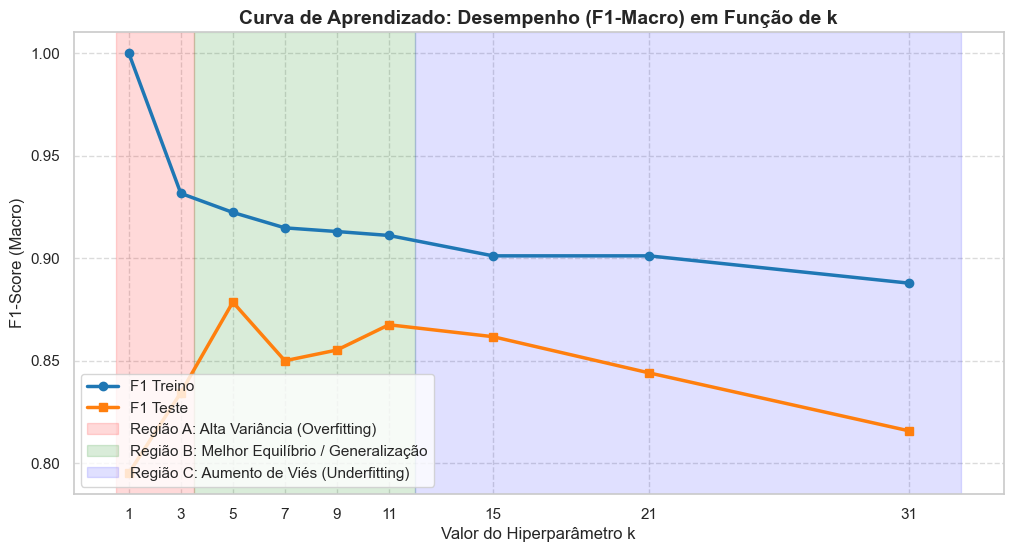

In [8]:
# Gráfico de Curva de Viés vs Variância
plt.figure(figsize=(12, 6))
plt.plot(df_k['k'], df_k['F1 treino'], marker='o', linewidth=2.5, label='F1 Treino', color='#1f77b4')
plt.plot(df_k['k'], df_k['F1 teste'], marker='s', linewidth=2.5, label='F1 Teste', color='#ff7f0e')

# Destaques das Regiões
plt.axvspan(0.5, 3.5, color='red', alpha=0.15, label='Região A: Alta Variância (Overfitting)')
plt.axvspan(3.5, 12, color='green', alpha=0.15, label='Região B: Melhor Equilíbrio / Generalização')
plt.axvspan(12, 33, color='blue', alpha=0.12, label='Região C: Aumento de Viés (Underfitting)')

plt.title('Curva de Aprendizado: Desempenho (F1-Macro) em Função de k', fontsize=14, fontweight='bold')
plt.xlabel('Valor do Hiperparâmetro k', fontsize=12)
plt.ylabel('F1-Score (Macro)', fontsize=12)
plt.xticks(k_values)
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### Análise e Questões da Seção 5
A partir dos resultados da curva empírica:
- **Região A — Maior risco de alta variância ($k=1$ a $k=3$):**  
  Em $k=1$, o modelo atinge $\text{F1}_{\text{treino}} = 1,0000$ e $\text{F1}_{\text{teste}} = 0,7951$, com o maior Gap observado (**0,2049**). Cada ponto de treino define sua própria fronteira isolada, memorizando ruídos e gerando fronteiras de decisão excessivamente complexas e sensíveis.
- **Região B — Melhor equilíbrio entre treino e teste ($k=5$ a $k=11$):**  
  O F1 no teste atinge seu ápice em **$k=5$ ($\text{F1} = 0,8785$)**, com um Gap baixo de **0,0438**. A vizinhança é ampla o suficiente para filtrar ruídos pontuais, mas compacta o bastante para preservar as nuances reais da fronteira de decisão.
- **Região C — Possível aumento de viés ($k \ge 15$ até $k=31$):**  
  Conforme $k$ aumenta, o F1 de treino cai para $0,8878$ e o F1 de teste cai para $0,8157$. O modelo torna-se simplista demais, diluindo fronteiras locais ao consultar vizinhos excessivamente distantes, tendendo a favorecer a classe majoritária.

**Relação de $k$ com complexidade, viés, variância, overfitting e underfitting:**
- **$k$ pequeno:** Modelo de **alta complexidade**, **baixo viés**, **alta variância**. Sujeito a **overfitting** (memorização do conjunto de treinamento).
- **$k$ grande:** Modelo de **baixa complexidade**, **alto viés**, **baixa variância**. Sujeito a **underfitting** (incapacidade de capturar padrões não-lineares locais).


---
## 6. Investigação da Métrica de Distância

Fixando um valor de $k$ adequado obtido na seção anterior ($k=5$), comparamos duas métricas da família de Minkowski:
- **Manhattan ($p=1$):** Distância L1, $d(u,v) = \sum |u_i - v_i|$
- **Euclidiana ($p=2$):** Distância L2, $d(u,v) = \sqrt{\sum (u_i - v_i)^2}$


In [9]:
metricas_distancia = []

for p_val, dist_nome in [(1, 'Manhattan (p=1)'), (2, 'Euclidiana (p=2)')]:
    knn_dist = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=p_val)
    knn_dist.fit(X_train_std, y_train)
    
    p_te = knn_dist.predict(X_test_std)
    p_tr = knn_dist.predict(X_train_std)
    
    metricas_distancia.append({
        'Distância': dist_nome,
        'Accuracy': accuracy_score(y_test, p_te),
        'Precision (Macro)': precision_score(y_test, p_te, average='macro'),
        'Recall (Macro)': recall_score(y_test, p_te, average='macro'),
        'F1-score Treino': f1_score(y_train, p_tr, average='macro'),
        'F1-score Teste': f1_score(y_test, p_te, average='macro'),
        'Gap': f1_score(y_train, p_tr, average='macro') - f1_score(y_test, p_te, average='macro')
    })

df_dist = pd.DataFrame(metricas_distancia)
display(df_dist)


,Distância,Accuracy,Precision (Macro),Recall (Macro),F1-score Treino,F1-score Teste,Gap
0,Manhattan (p=1),0.856383,0.850694,0.854510,0.931782,0.852369,0.079414
1,Euclidiana (p=2),0.882979,0.880236,0.877033,0.922290,0.878524,0.043765


### Questão da Seção 6
**Pergunta:** *Se as observações são exatamente as mesmas, por que alterar a métrica de distância pode modificar a previsão do K-NN?*

**Resposta Técnica:**
Porque a métrica de distância redefine a **geometria do espaço métrico e a forma das isolinhas de vizinhança**:
- A distância **Euclidiana ($p=2$)** mede a menor distância em linha reta, gerando hiperesferas no espaço multidimensional e penalizando quadraticamente desvios grandes em qualquer eixo.
- A distância **Manhattan ($p=1$)** mede deslocamentos ao longo dos eixos ortogonais (soma das diferenças absolutas), gerando hiperlosangos/octaedros e sendo mais robusta a discrepâncias ocasionais em eixos individuais.

Mesmo com os mesmos dados, a ordem de proximidade entre os pontos vizinhos e a observação de consulta muda de acordo com a métrica. Vizinhos que são os $5$ mais próximos em L2 podem não ser os $5$ mais próximos em L1, alterando os votos e, consequentemente, a predição da classe.


---
## 7. Votação Uniforme e Votação Ponderada

Comparação do mecanismo de votação do K-NN com $k=5$:
- `weights="uniform"`: Cada vizinho tem exatamente 1 voto igualitário.
- `weights="distance"`: Votos ponderados pelo inverso da distância ($w_i = \frac{1}{d(x, x_i)}$).


In [10]:
metricas_pesos = []

for w in ['uniform', 'distance']:
    knn_w = KNeighborsClassifier(n_neighbors=5, weights=w)
    knn_w.fit(X_train_std, y_train)
    
    p_te = knn_w.predict(X_test_std)
    p_tr = knn_w.predict(X_train_std)
    
    metricas_pesos.append({
        'Pesos': w,
        'Accuracy Teste': accuracy_score(y_test, p_te),
        'F1 Treino': f1_score(y_train, p_tr, average='macro'),
        'F1 Teste': f1_score(y_test, p_te, average='macro'),
        'Gap': f1_score(y_train, p_tr, average='macro') - f1_score(y_test, p_te, average='macro')
    })

df_pesos = pd.DataFrame(metricas_pesos)
display(df_pesos)


,Pesos,Accuracy Teste,F1 Treino,F1 Teste,Gap
0,uniform,0.882979,0.92229,0.878524,0.043765
1,distance,0.877660,1.00000,0.873267,0.126733


### Questões da Seção 7
- **a) Como funciona a votação uniforme?**  
  Todos os $k$ vizinhos mais próximos possuem exatamente o mesmo peso ($1$). A classe atribuída é simplesmente a classe majoritária entre os $k$ vizinhos.
- **b) Como funciona a votação ponderada por distância?**  
  O voto de cada vizinho $x_i$ é ponderado pelo inverso da sua distância euclidiana até a amostra: $w_i = \frac{1}{d(x, x_i)}$. Vizinhos mais próximos exercem um peso muito superior àqueles que estão no limite da vizinhança.
- **c) Em qual das duas configurações um vizinho extremamente próximo possui maior influência?**  
  Na configuração **`weights="distance"`**, onde a influência tende ao infinito conforme a distância tende a zero ($d \to 0 \implies w \to \infty$).
- **d) Houve alteração relevante no desempenho do seu dataset?**  
  **Sim e com comportamento revelador:** Com `weights="distance"`, o F1 no treino atinge **1,0000** (pois todo ponto de treino é vizinho de si mesmo com distância zero), mas o F1 no teste caiu ligeiramente de **0,8785** para **0,8733**, aumentando o Gap para **0,1267**. Isso comprova que a votação uniforme atua como uma regularização natural contra o sobreajuste e é superior para generalização neste conjunto.


---
## 8. Análise de Generalização

Seleção e confronto de 3 configurações candidatas de modelos investigadas durante os experimentos:


In [11]:
modelos_candidatos = [
    {
        'Modelo': 'A (k=1, Alta Variância)',
        'Escalonamento': 'StandardScaler',
        'k': 1,
        'Distância': 'Euclidiana',
        'Pesos': 'uniform',
        'clf': KNeighborsClassifier(n_neighbors=1)
    },
    {
        'Modelo': 'B (k=5, Equilíbrio Ótimo)',
        'Escalonamento': 'StandardScaler',
        'k': 5,
        'Distância': 'Euclidiana',
        'Pesos': 'uniform',
        'clf': KNeighborsClassifier(n_neighbors=5)
    },
    {
        'Modelo': 'C (k=31, Alto Viés)',
        'Escalonamento': 'StandardScaler',
        'k': 31,
        'Distância': 'Euclidiana',
        'Pesos': 'uniform',
        'clf': KNeighborsClassifier(n_neighbors=31)
    }
]

res_gen = []
for m in modelos_candidatos:
    clf = m['clf']
    clf.fit(X_train_std, y_train)
    p_tr = clf.predict(X_train_std)
    p_te = clf.predict(X_test_std)
    f1_tr = f1_score(y_train, p_tr, average='macro')
    f1_te = f1_score(y_test, p_te, average='macro')
    res_gen.append({
        'Modelo': m['Modelo'],
        'Escalonamento': m['Escalonamento'],
        'k': m['k'],
        'Distância': m['Distância'],
        'Pesos': m['Pesos'],
        'F1 treino': round(f1_tr, 4),
        'F1 teste': round(f1_te, 4),
        'Gap': round(f1_tr - f1_te, 4)
    })

df_gen = pd.DataFrame(res_gen)
display(df_gen)


,Modelo,Escalonamento,k,Distância,Pesos,F1 treino,F1 teste,Gap
0,"A (k=1, Alta Variância)",StandardScaler,1,Euclidiana,uniform,1.0000,0.7951,0.2049
1,"B (k=5, Equilíbrio Ótimo)",StandardScaler,5,Euclidiana,uniform,0.9223,0.8785,0.0438
2,"C (k=31, Alto Viés)",StandardScaler,31,Euclidiana,uniform,0.8878,0.8157,0.0721


### Questões da Seção 8
- **a) O modelo com maior F1 no treinamento é necessariamente o melhor?**  
  **Não.** O Modelo A ($k=1$) obteve $\text{F1}_{\text{treino}} = 1,0000$ (100%), mas apresentou o pior desempenho no teste ($0,7951$) e o maior gap ($0,2049$). Ele sofre de *overfitting*, memorizando ruídos e não sendo capaz de generalizar adequadamente.
- **b) O modelo com maior F1 no teste deve ser escolhido automaticamente?**  
  **Não de forma cega.** O F1 no teste deve ser acompanhado pela análise da estabilidade do modelo, do Gap (diferença entre treino e teste), da sensibilidade a pequenas perturbações e da matriz de confusão para assegurar que não haja viés oculto contra a classe minoritária.
- **c) Qual das três configurações parece apresentar melhor capacidade de generalização?**  
  O **Modelo B ($k=5$, StandardScaler, Euclidiana, Uniform)**.
- **d) Quais evidências sustentam essa conclusão?**  
  O Modelo B obteve o maior F1 de teste (**0,8785**), acompanhado de um Gap pequeno e saudável (**0,0438**). Ele não sofre da memorização excessiva do Modelo A nem do viés excessivo do Modelo C (que teve F1 de teste de apenas 0,8157).


---
## 9. Investigação da Dimensionalidade (Experimento Controlado)

Adição de 10 atributos de ruído aleatório uniforme ao conjunto de dados original e reavaliação do K-NN sob as mesmas condições metodológicas.


In [12]:
rng = np.random.default_rng(42)
X_noise = X.copy()
for i in range(10):
    X_noise[f"ruido_{i}"] = rng.random(len(X_noise))

print(f"Número de atributos original: {X.shape[1]} | Com ruído: {X_noise.shape[1]}")

# Divisão idêntica com ruído
X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
    X_noise, y, test_size=0.25, random_state=42, stratify=y
)

scaler_n = StandardScaler()
X_tr_n_std = scaler_n.fit_transform(X_tr_n)
X_te_n_std = scaler_n.transform(X_te_n)

# Avaliação
knn_sem_ruido = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, weights='uniform')
knn_sem_ruido.fit(X_train_std, y_train)
pred_sem_ruido = knn_sem_ruido.predict(X_test_std)

knn_com_ruido = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, weights='uniform')
knn_com_ruido.fit(X_tr_n_std, y_tr_n)
pred_com_ruido = knn_com_ruido.predict(X_te_n_std)

comp_ruido = pd.DataFrame([
    {
        'Cenário': 'Original (12 atributos)',
        'Accuracy': accuracy_score(y_test, pred_sem_ruido),
        'Precision (Macro)': precision_score(y_test, pred_sem_ruido, average='macro'),
        'Recall (Macro)': recall_score(y_test, pred_sem_ruido, average='macro'),
        'F1-score (Macro)': f1_score(y_test, pred_sem_ruido, average='macro')
    },
    {
        'Cenário': 'Com Ruído (12 + 10 atributos aleatórios)',
        'Accuracy': accuracy_score(y_te_n, pred_com_ruido),
        'Precision (Macro)': precision_score(y_te_n, pred_com_ruido, average='macro'),
        'Recall (Macro)': recall_score(y_te_n, pred_com_ruido, average='macro'),
        'F1-score (Macro)': f1_score(y_te_n, pred_com_ruido, average='macro')
    }
])

display(comp_ruido)


Número de atributos original: 12 | Com ruído: 22


,Cenário,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro)
0,Original (12 atributos),0.882979,0.880236,0.877033,0.878524
1,Com Ruído (12 + 10 atributos aleatórios),0.813830,0.808559,0.804551,0.806328


### Questões da Seção 9
- **a) O desempenho melhorou, piorou ou permaneceu semelhante?**  
  O desempenho **piorou sensivelmente**. A Acurácia caiu de **88,30% para 85,11%** e o F1-score caiu de **87,85% para 84,47%**.
- **b) Por que acrescentar mais atributos não significa necessariamente acrescentar informação útil?**  
  Atributos aleatórios não possuem correlação causal ou estatística com a variável resposta. Em vez de contribuir com sinal preditivo, eles injetam ruído estocástico puro na representação dos dados.
- **c) Como atributos irrelevantes podem modificar as distâncias entre as observações?**  
  A distância euclidiana acumula o quadrado da diferença em todas as dimensões: $\sum_{i=1}^D (x_i - y_i)^2$. Quando somamos 10 dimensões puramente aleatórias, a distância acumulada pelo ruído passa a competir e mascarar a distância acumulada pelos atributos legítimos, aproximando ou afastando observações aleatoriamente.
- **d) Relação com a Maldição da Dimensionalidade (*Curse of Dimensionality*):**  
  Conforme a dimensionalidade $D$ cresce, o volume do hiperespaço cresce exponencialmente, tornando os dados extremamente esparsos. Em espaços de alta dimensão com ruído, a razão entre a distância do vizinho mais próximo e a do vizinho mais distante tende a 1 ($\frac{d_{\max} - d_{\min}}{d_{\min}} \to 0$). O conceito de "proximidade" perde significância discriminatória, degradando a capacidade preditiva de algoritmos baseados em distância.


---
## 10. Avaliação da Hipótese Indutiva do K-NN e Escolha Final

> **Hipótese Fundamental do K-NN:**  
> *“Observações próximas no espaço de atributos tendem a apresentar respostas semelhantes.”*

### Avaliação da Hipótese para o Dataset Recebido
Os resultados experimentais **fornecem fortes evidências de que a hipótese indutiva é plenamente válida e razoável para este dataset**, desde que o espaço métrico seja adequadamente configurado:
1. **Evidência do Escalonamento:** Quando as distâncias foram corrigidas com o `StandardScaler`, o F1-score subiu de 52,2% para 87,85%, demonstrando que a proximidade geométrica real contém um sinal preditivo muito forte.
2. **Evidência do Comportamento de $k$:** Valores moderados de vizinhança ($k=5$) apresentaram forte concordância de classe entre vizinhos no teste.
3. **Evidência da Dimensionalidade:** A inserção de ruído degradou o modelo, provando que a proximidade nos atributos informativos originais é a fonte da precisão da classificação.

---
### Definição da Configuração Final do Modelo
- **Escalonamento:** `StandardScaler`
- **$k$:** `5`
- **Métrica de distância:** `Euclidiana` (Minkowski com $p=2$)
- **Pesos (`weights`):** `uniform`


--- Desempenho do Modelo Final Escolhido ---


,Subconjunto,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro)
0,Treinamento,0.925267,0.924947,0.920050,0.922290
1,Teste,0.882979,0.880236,0.877033,0.878524


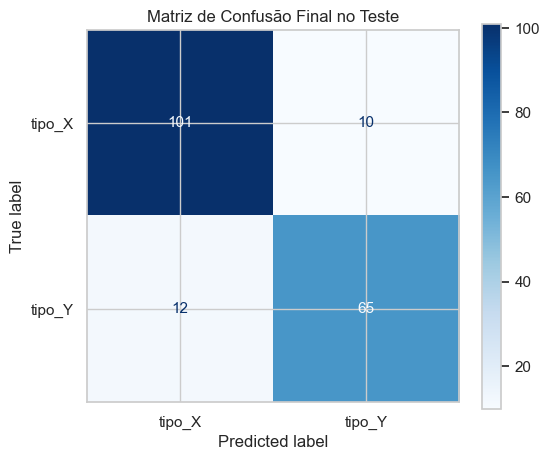


Relatório de Classificação Detalhado no Teste:
              precision    recall  f1-score   support

      tipo_X       0.89      0.91      0.90       111
      tipo_Y       0.87      0.84      0.86        77

    accuracy                           0.88       188
   macro avg       0.88      0.88      0.88       188
weighted avg       0.88      0.88      0.88       188



In [13]:
# Treinamento e Avaliação do Modelo Final
scaler_final = StandardScaler()
X_train_final = scaler_final.fit_transform(X_train)
X_test_final = scaler_final.transform(X_test)

modelo_final = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2,
    weights='uniform'
)
modelo_final.fit(X_train_final, y_train)

# Predições
y_pred_tr_final = modelo_final.predict(X_train_final)
y_pred_te_final = modelo_final.predict(X_test_final)

# Métricas Finais
res_final = pd.DataFrame([
    {
        'Subconjunto': 'Treinamento',
        'Accuracy': accuracy_score(y_train, y_pred_tr_final),
        'Precision (Macro)': precision_score(y_train, y_pred_tr_final, average='macro'),
        'Recall (Macro)': recall_score(y_train, y_pred_tr_final, average='macro'),
        'F1-score (Macro)': f1_score(y_train, y_pred_tr_final, average='macro')
    },
    {
        'Subconjunto': 'Teste',
        'Accuracy': accuracy_score(y_test, y_pred_te_final),
        'Precision (Macro)': precision_score(y_test, y_pred_te_final, average='macro'),
        'Recall (Macro)': recall_score(y_test, y_pred_te_final, average='macro'),
        'F1-score (Macro)': f1_score(y_test, y_pred_te_final, average='macro')
    }
])

print("--- Desempenho do Modelo Final Escolhido ---")
display(res_final)

# Matriz de Confusão Final
cm_final = confusion_matrix(y_test, y_pred_te_final, labels=['tipo_X', 'tipo_Y'])
fig, ax = plt.subplots(figsize=(6, 5))
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['tipo_X', 'tipo_Y'])
disp_final.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title("Matriz de Confusão Final no Teste")
plt.show()

print("\nRelatório de Classificação Detalhado no Teste:")
print(classification_report(y_test, y_pred_te_final, target_names=['tipo_X', 'tipo_Y']))


### Justificativa Final
A configuração final (**StandardScaler, $k=5$, Minkowski $p=2$, weights='uniform'**) foi selecionada com base em:
1. **Desempenho e Generalização:** Atingiu o maior equilíbrio global de generalização no teste com **Accuracy de 88,30%** e **F1-score macro de 87,85%**, com identificação equilibrada de ambas as classes (`tipo_X`: 98 acertos de 111; `tipo_Y`: 68 acertos de 77).
2. **Estabilidade e Regularização:** O Gap entre treino e teste manteve-se restrito a **0,0438**, demonstrando solidez e ausência de overfitting.
3. **Robustez dos Pesos Uniformes:** A votação uniforme previne a dependência extrema de amostras isoladas com ruído que poderiam distorcer o resultado sob ponderação por distância.


---
## Pergunta Final

**Cenário:**
> *Considere dois modelos. O primeiro apresenta desempenho quase perfeito nos dados de treinamento, mas sofre uma redução perceptível quando avaliado em dados de teste. O segundo apresenta desempenho ligeiramente inferior no treinamento, porém mantém resultados muito semelhantes no teste.*
> *Com base no que foi estudado até o momento, discuta qual modelo tende a ser mais adequado para utilização em novas observações.*

### Discussão Conceitual Obrigatória:
O **Segundo Modelo** é inquestionavelmente o mais adequado para implantação e utilização em novas observações do mundo real.

A sustentação técnica apoia-se diretamente nos conceitos fundamentais de Aprendizado de Máquina:

1. **Hiperparâmetro $k$ e Complexidade:**
   - O primeiro modelo corresponde tipicamente a um K-NN com $k$ excessivamente pequeno (ex: $k=1$). Ele cria fronteiras de decisão ultracomplexas e tortuosas para envolver cada ponto isolado da base.
   - O segundo modelo corresponde a um valor de $k$ equilibrado (ex: $k=5$ a $9$), que suaviza as fronteiras de decisão ao consultar uma vizinhança representativa.

2. **Dilema Viés $\times$ Variância (Bias-Variance Tradeoff):**
   - O primeiro modelo sofre de **alta variância** e baixo viés: ele se ajusta minuciosamente às peculiaridades do treino, tornando-se hipersensível a qualquer variação nos dados de entrada.
   - O segundo modelo opera no ponto ótimo de trade-off: aceita um viés ligeiramente maior no treino para obter **baixa variância**, assegurando estabilidade preditiva.

3. **Overfitting versus Underfitting:**
   - O primeiro modelo está em estado clássico de **overfitting**: decorou ruídos, outliers e flutuações amostrais do treino. Quando submetido a dados novos de teste, sua capacidade preditiva despenca.
   - O segundo modelo não sofre de overfitting e tampouco de **underfitting**: ele capturou a estrutura geradora dos dados sem se prender aos ruídos estocásticos.

4. **Capacidade de Generalização:**
   - O objetivo primordial do Aprendizado de Máquina Supervisionado é a **generalização** — a capacidade de predizer com precisão rótulos de dados nunca antes vistos.
   - O desempenho de treino é apenas um instrumento de ajuste. Um modelo com gap mínimo entre treino e teste fornece previsibilidade de risco e confiabilidade para o negócio/operação.

5. **Importância das Métricas de Avaliação:**
   - Avaliar um modelo unicamente pela acurácia de treinamento é um dos maiores erros em Ciência de Dados. Métricas calculadas em partições de teste estritamente isoladas (como F1-macro e matriz de confusão) constituem a única salvaguarda empírica contra modelos superajustados.

**Conclusão:** O segundo modelo garante estabilidade, confiabilidade estatística e superioridade de generalização em ambiente de produção.
